**420-A58-SF - Algorithmes d'apprentissage non supervisé - Hiver 2026 - Spécialisation technique en Intelligence Artificielle**<br/>
MIT License - Copyright (c) 2026 Mikaël Swawola
<br/>
![Travaux Pratiques - partitionnement-k-moyennes (implementation)](static/01-02-A1-banner.png)
<br/>
**Objectif:** cette séance de travaux pratiques a pour objectif l'implémentation sous forme de code Python de l'**algorithme des K-moyennes** et de sa mise en œuvre

In [64]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

## 1 - Lecture des données

**Exercice 1 - À l'aide de la librairie Pandas, lire le fichier de données `blobs.csv`**

In [65]:
# Compléter cette cellule ~ 2 lignes de code

In [66]:
import pandas as pd
blobs = pd.read_csv('../../data/blobs.csv')

## 2 - Visualisation des données

**Exercice 2 - En utilisant un type de graphique approprié, visualiser les données. Combien de clusters semblent présents ?**

In [67]:
# Compléter cette cellule ~ de 2 à 7 lignes de code

In [68]:
blobs.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x0      1000 non-null   float64
 1   x1      1000 non-null   float64
dtypes: float64(2)
memory usage: 15.8 KB


In [69]:
import seaborn as sns; sns.set()
import matplotlib.pyplot as plt
# Configuration de la visualisation
sns.set(style="darkgrid")
sns.set_context("notebook", font_scale=1.5, rc={"lines.linewidth": 2.5})
plt.rcParams['figure.figsize']=(12,8)

Text(0, 0.5, 'x1')

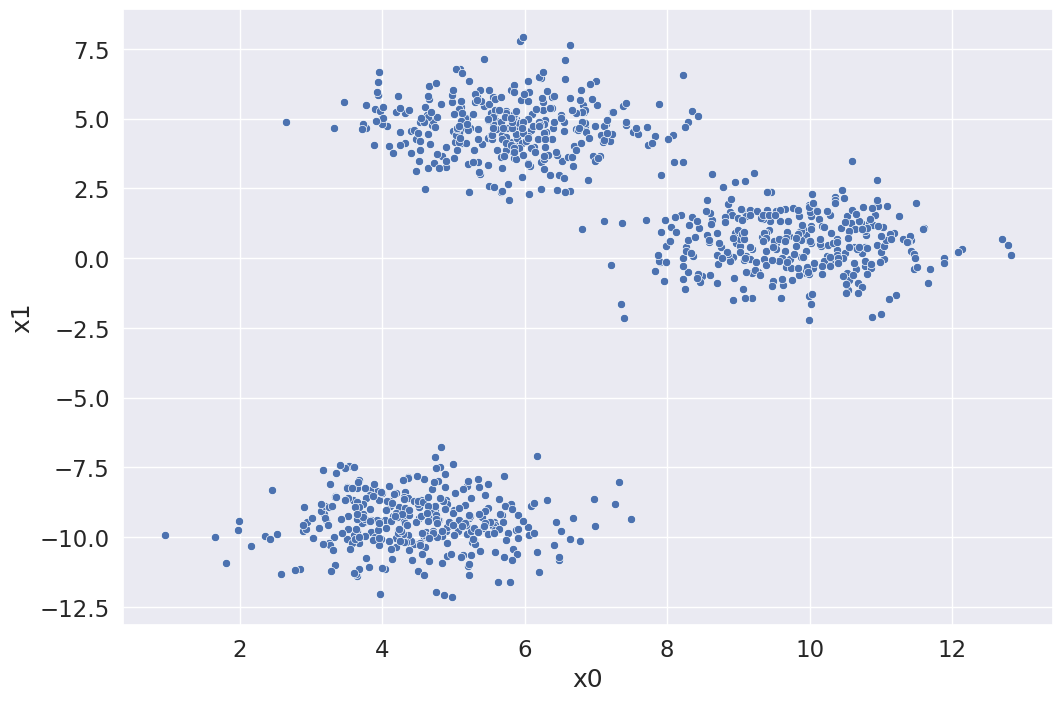

In [70]:
_ = sns.scatterplot(x="x0", y="x1", data=blobs)
plt.xlabel('x0')
plt.ylabel('x1')

## 3 - Implémentation de l'algorithme des K-moyennes

**Exercice 3-1 - Initialiser la variable K, représentant le nombre de clusters estimé à partir de la visualisation précédente**

In [71]:
# Compléter cette cellule ~ 1 ligne de code

In [72]:
K = 3

**Exercice 3-2 - Mettre les données à l'échelle. Visualiser de nouveau les données**

In [73]:
# Compléter cette cellule ~ 3 lignes de code

In [74]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(blobs)

Text(0, 0.5, 'x1')

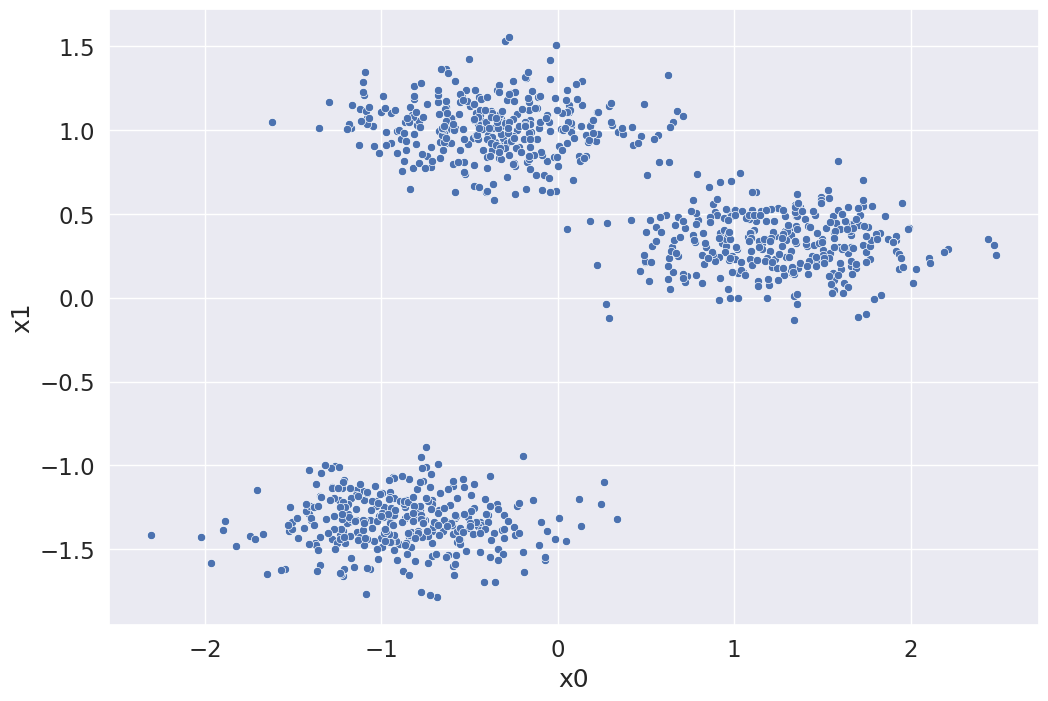

In [75]:
ax = sns.scatterplot(x=X[:,0], y=X[:,1])
plt.xlabel('x0')
plt.ylabel('x1')

**Exercice 3-3 - Initialiser les K centroïdes. Pour ce, vous pouvez choisir aléatoirement K observations.** 

In [76]:
# Compléter cette cellule ~ de 2 à 4 lignes de code

In [77]:
import numpy as np
np.random.seed(2023)
random_observations = np.random.choice(X.shape[0], size=K, replace=False)
centroids = X[random_observations]
centroids

array([[-0.78374588, -1.09767698],
       [-0.76494377,  1.07966587],
       [ 1.83367271,  0.0181017 ]])

**Exercice 3-4 - Sur la visualisation, afficher la position des K centroïdes initiaux**

In [78]:
# Compléter cette cellule ~ de 2 à 4 lignes de code

Text(0, 0.5, 'x1')

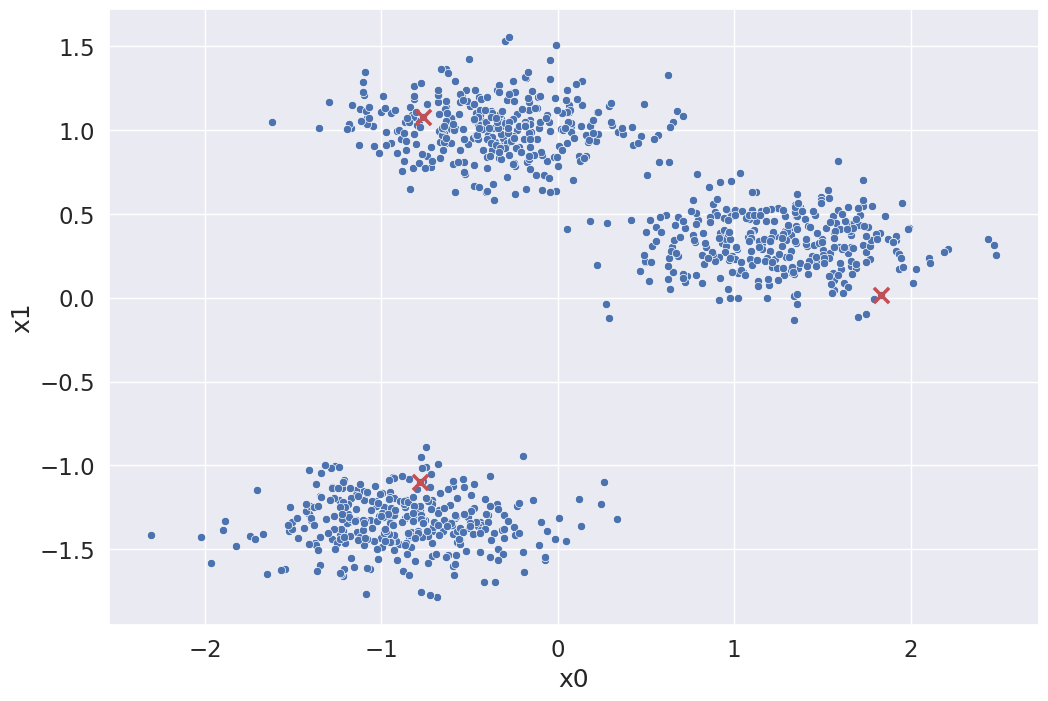

In [79]:
ax = sns.scatterplot(x=X[:,0], y=X[:,1])
plt.scatter(centroids[:,0], centroids[:,1], c='r', marker='x', s=120)
plt.xlabel('x0')
plt.ylabel('x1')

**Exercice 3-5 - Afin de faciliter l'implémentation ultérieure de l'algorithme des K-moyennes, calculer la distance euclidienne (L2) entre le point A (-1,-1) et chacun des K centroïdes. Trouver ensuite l'index du centroïde le plus proche**

In [80]:
# Compléter cette cellule ~ 4 lignes de code

In [81]:
A = np.array([-1,-1])
# Remarque concernant le calcul des distances
print(f'A = \n{A}')
print(f'centroids = \n{centroids}')
print(f'A-centroids = \n{centroids-A}')

A = 
[-1 -1]
centroids = 
[[-0.78374588 -1.09767698]
 [-0.76494377  1.07966587]
 [ 1.83367271  0.0181017 ]]
A-centroids = 
[[ 0.21625412 -0.09767698]
 [ 0.23505623  2.07966587]
 [ 2.83367271  1.0181017 ]]


In [82]:
L2 = np.sqrt(np.sum((centroids-A)**2, axis=1))
plus_proche = np.argmin(L2)

print(f'Centroïde le plus proche: {plus_proche} - {centroids[plus_proche,:]} ({np.min(L2)})')

Centroïde le plus proche: 0 - [-0.78374588 -1.09767698] (0.23729020144775473)


**Exercice 3-6 - Implémenter l'algorithme des K-moyennes tel que vu en cours. Pour appel, le *pseudo code* de l'algorithme est le suivant:**
* Choix de K (fait plus haut, exercice 3-1)
* Standardisation des données (fait plus haut, exercice 3-2)
* Initialisation des K centroïdes (fait plus haut, exercice 3-3)
* Pour n_iterations: **(partie à coder !)**
    * Assignation des observations à un cluster (centroïde le plus "proche"). La distance euclidienne sera utilisée ici (exercice 3-5)
    * Déplacement des centroïdes (moyenne des observations associées à un cluster)

<details>
<summary>
    <font size="3" color="darkgreen"><b>Cliquer ici pour obtenir un indice</b></font>
</summary>
<p>
Vous devrez créer un tableau représentant le cluster associé à chaque observation
</p>

In [83]:
# Compléter cette cellule ~ de 10 à 20 lignes de code

In [84]:
max_iter = 10
c = np.zeros(shape=(X.shape[0], 1))

for i in range(1, max_iter):
    
    # Assignation à un cluster
    for j, x in enumerate(X):
        L2 = np.sqrt(np.sum((centroids-x)**2, axis=1))
        c[j] = np.argmin(L2)
    
    # Calcul des K moyennes
    for k in range(0, K):
        mask = (c == k).flatten()
        kmean = X[mask, :].mean(axis=0)
        centroids[k,:] = kmean   

**Exercice 3-7 - Afficher la position des clusters. Visualiser également les observations et leur association à un des K clusters**

<details>
<summary>
    <font size="3" color="darkgreen"><b>Cliquer ici pour obtenir un indice</b></font>
</summary>
<p>
Utiliser `hue`
</p>

In [85]:
# Compléter cette cellule ~ de 2 à 4 lignes de code

Text(0, 0.5, 'x1')

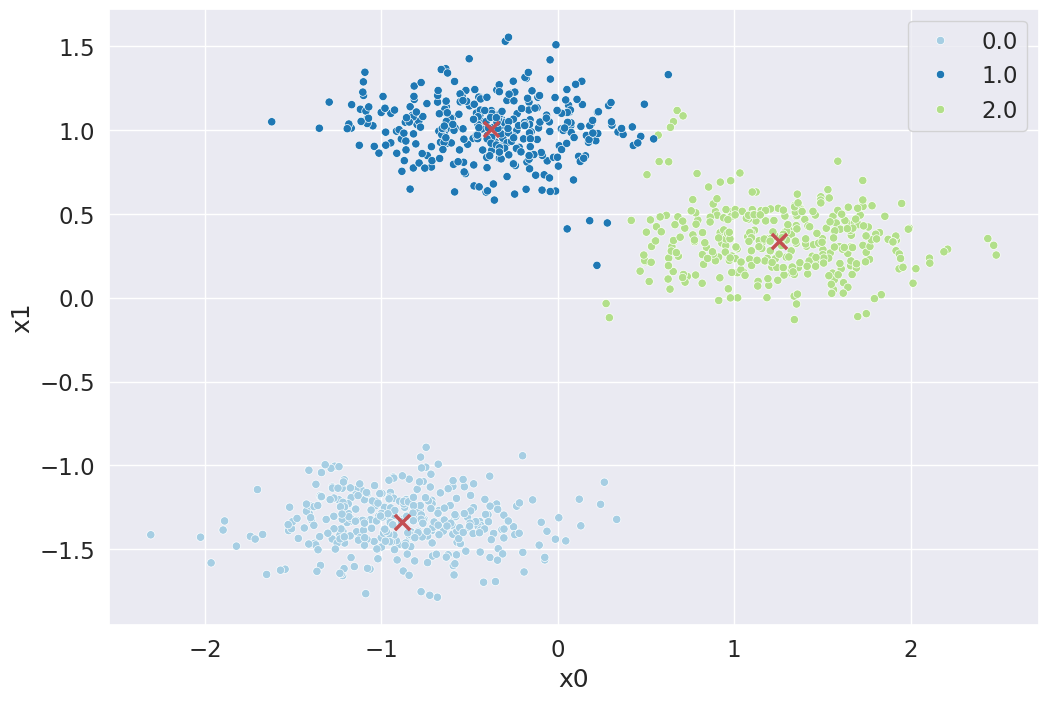

In [86]:
ax = sns.scatterplot(x=X[:,0], y=X[:,1], hue=c[:,0], palette="Paired")
plt.scatter(centroids[:,0], centroids[:,1], c='r', marker='x', s=120)
plt.xlabel('x0')
plt.ylabel('x1')

**Exercice 3-8 - Calculer la distorsion**

In [87]:
# Compléter cette cellule ~ 2 lignes de code

In [88]:
mu_c = centroids[c.ravel().astype(int),:]

In [89]:
distances = np.sum(np.sqrt(np.sum((X - mu_c)**2, axis=1)))
distorsion = distances / X.shape[0]
distorsion

np.float64(0.3790914170625205)

## 4 - Intégration de l'algorithme dans une fonction

**Exercice 4 - Intégrer l'ensemble de l'algorithme des K-moyennes, incluant l'initalisation aléatoire des K centroïdes `n_init` fois, dans une fonction**
<br/>
* Cette fonction prend en argument les données, le nombre de clusters, le nombre d'itérations de l'algorithme et le nombre d'initialisations aléatoires des K centroïdes
* Les valeurs retournées sont la distorsion et les centroïdes

In [90]:
# Compléter cette cellule

In [91]:
def kmeans(data, K, max_iter=10, n_init=10):
    
    best = None
    distorsion = 1e15
    for n in range(1, n_init):
        # Intialisation des centroides
        sel = np.random.choice(data.shape[0], size=K, replace=False)
        centroids = data[sel]

        c = np.zeros(shape=(data.shape[0], 1))

        for i in range(1, max_iter):
            # Cluster assignement
            for j, x in enumerate(data):                
                L2 = np.sqrt(np.sum((centroids-x)**2, axis=1))
                c[j] = np.argmin(L2)

            # Move centroid
            for k in range(0, K):
                mask = (c == k).ravel()
                kmean = X[mask, :].mean(axis=0)
                centroids[k,:] = kmean 
            
            # Distorsion
            mu_c = centroids[c.ravel().astype(int),:]
            d = np.sum(np.sqrt(np.sum((data - mu_c)**2, axis=1))) / data.shape[0]
            if d < distorsion:
                best = centroids
                distorsion = d
    
    return distorsion, best        

In [92]:
best_disto, best_centroids = kmeans(X, K=3)

In [93]:
print(f'Distorsion:\n{best_disto}\nCentroïdes:\n{best_centroids}')

Distorsion:
0.37907810944396725
Centroïdes:
[[-0.88493914 -1.33551255]
 [-0.37870165  1.00631544]
 [ 1.25161077  0.33921755]]


Text(0, 0.5, 'x1')

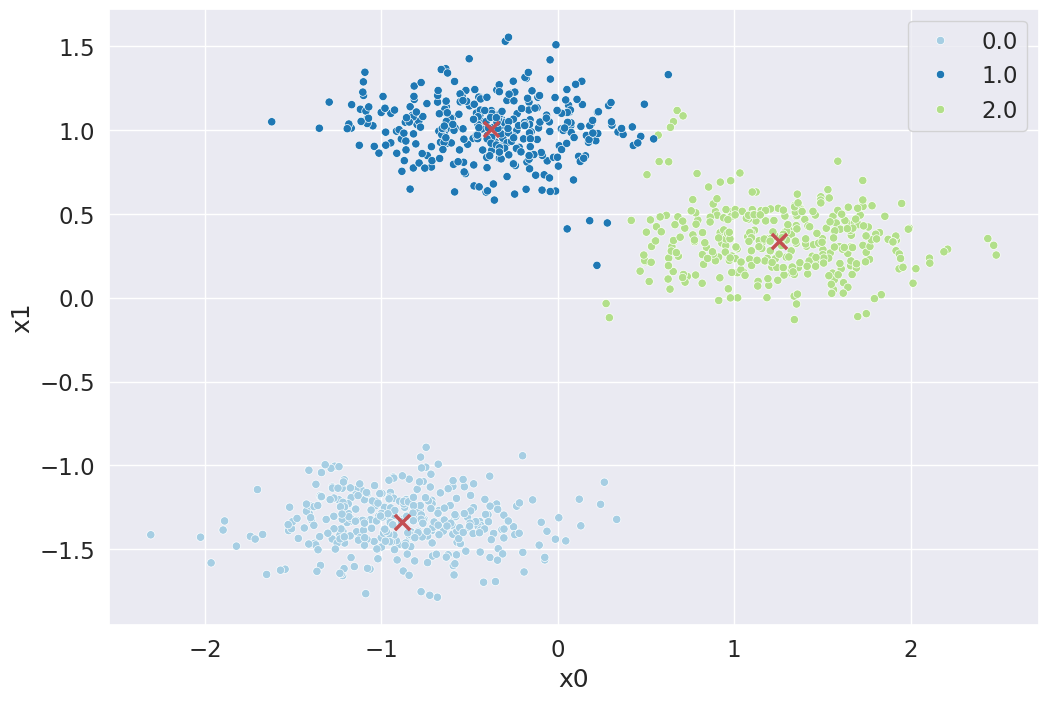

In [31]:
ax = sns.scatterplot(x=X[:,0], y=X[:,1], hue=c[:,0], palette="Paired")
plt.scatter(best_centroids[:,0], best_centroids[:,1], c='r', marker='x', s=120)
plt.xlabel('x0')
plt.ylabel('x1')

## 5 - Nombre optimal de centroïdes

**Exercice 5 - Faire varier le nombre de centroïdes K de 2 à 10 et vérifier sa valeur optimale à l'aide de la technique du "coude"**

In [32]:
# Compléter la cellule ~ 4-5 lignes de code

In [33]:
J = []
for k in range(2,10+1):
    j, _ = kmeans(X, K=k)
    J.append(j)

Text(0, 0.5, 'Distorsion')

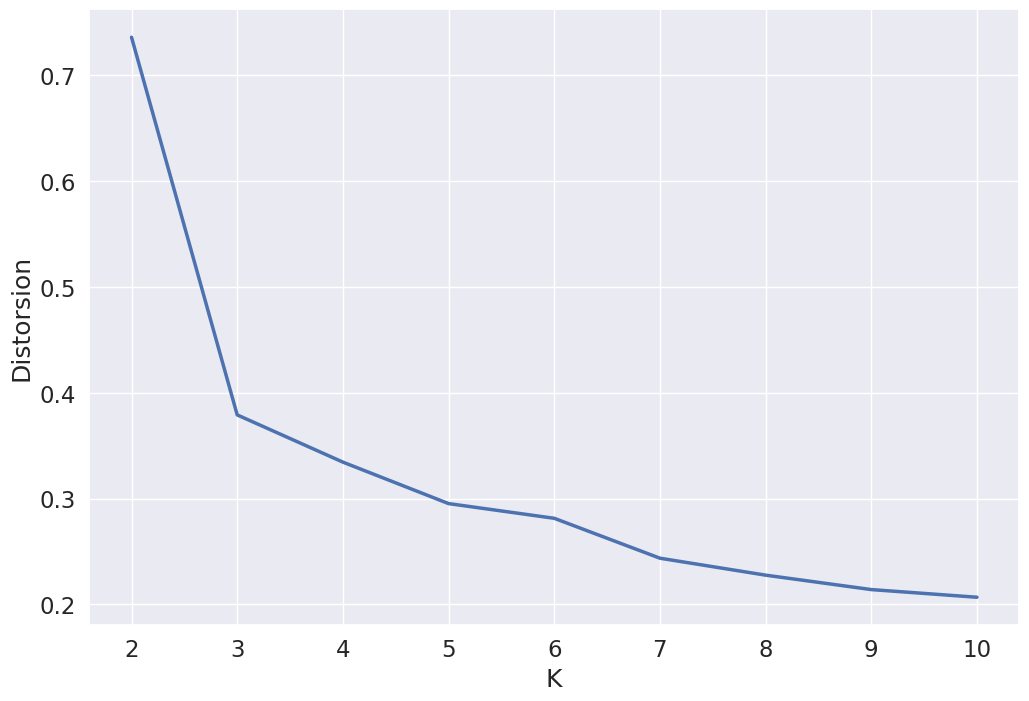

In [34]:
plt.plot(range(2,10+1), J)
plt.xlabel('K')
plt.ylabel('Distorsion')

## 6 - Exercices optionnels

**Exercice 6-1 - Ajouter un critère de convergence**

In [ ]:
# Compléter la cellule

**Exercice 6-2 - Suppression des clusters vides**

In [ ]:
# Compléter la cellule

**Fin de l'atelier 01-02-A1**